# Computer Exercise 14.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구(Applied Case Studies) 확장
> **단원**: §14.2 Case Studies — *Hyperparameter Search: Grid vs Random vs Bayesian Optimization*
> **풀이 일자**: Day 58
> **언어**: Python 3 (NumPy / pandas / Matplotlib / SciPy)

## 1. 문제 (원문)

> **3.** An expensive black-box objective $f(\mathbf x)$ must be **minimized** over a low-dimensional
> hyperparameter box, under a *fixed evaluation budget* $N$. Compare three strategies —
> **grid search**, **random search**, and **Bayesian optimization** (a Gaussian-process surrogate with
> the *Expected-Improvement* acquisition). Plot the **best-so-far** value versus the number of
> evaluations, averaged over several seeds, and explain which strategy uses the budget most efficiently.

### 한국어 풀이용 정리
평가가 비싼 블랙박스 $f(\mathbf x)$ 를 *정해진 예산* $N$ 안에서 최소화한다. 세 탐색전략 —
**그리드**, **랜덤**, **베이지안 최적화(GP 대리모형 + 기대개선 EI)** — 을 같은 예산에서 맞붙이고,
**best-so-far(현재까지 최선값)** 를 평가횟수의 함수로 그려 어떤 전략이 예산을 가장 효율적으로 쓰는지
설명한다. 목적함수는 2차원 **Branin** (전역최소 $\approx 0.3979$).

## 2. 수학적 배경

### 2.1 대리모형: 가우시안 과정(GP)
관측 $\{(\mathbf x_i,y_i)\}$ 에 대해 GP는 임의 점 $\mathbf x_\ast$ 에서의 값을 정규분포로 예측한다.
RBF 커널 $k(\mathbf x,\mathbf x')=\sigma_f^2\exp(-\|\mathbf x-\mathbf x'\|^2/2\ell^2)$ 로
$$
\mu(\mathbf x_\ast)=\mathbf k_\ast^\top (K+\sigma_n^2 I)^{-1}\mathbf y,\qquad
s^2(\mathbf x_\ast)=k_{\ast\ast}-\mathbf k_\ast^\top (K+\sigma_n^2 I)^{-1}\mathbf k_\ast .
$$
$\mu$ 는 예측 평균, $s$ 는 **불확실성**(탐험의 근거).

### 2.2 획득함수: 기대개선(Expected Improvement)
현재 최선값 $y^{+}=\min_i y_i$ 에 대해, 최소화 문제에서 개선량 $I(\mathbf x)=\max(y^{+}-\mu,0)$ 의 기대값은
닫힌형으로
$$
\boxed{\;\operatorname{EI}(\mathbf x)=(y^{+}-\mu-\xi)\,\Phi(z)+s\,\phi(z),\quad z=\frac{y^{+}-\mu-\xi}{s}\;}
$$
$\Phi,\phi$ 는 표준정규 CDF/PDF, $\xi\ge0$ 는 탐험 여유. EI는 **낮은 평균(활용)** 과 **큰 불확실성(탐험)** 을
동시에 보상해, 다음 평가점을 자동으로 고른다.

### 2.3 세 전략
- **Grid**: 정규격자를 순서대로 평가 — 차원저주에 약하고 결정론적.
- **Random**: 균등난수로 평가 — 저차원 유효구조가 있을 때 격자보다 강함(Bergstra–Bengio).
- **Bayesian(GP+EI)**: 과거 평가로 대리모형을 갱신하며 *정보가 많은 점* 만 골라 평가 — 예산이 빠듯할수록 유리.

## 3. 풀이 흐름

1. **목적함수** Branin $f(x_1,x_2)$ 와 정의역 박스 설정(전역최소 $\approx0.3979$).
2. **Grid**: $\lceil\sqrt N\rceil\times\lceil\sqrt N\rceil$ 격자에서 $N$ 개 평가.
3. **Random**: 박스 안 균등표집 $N$ 개 (여러 시드 평균).
4. **Bayesian**: 소수의 초기 랜덤점 → 반복 [GP 적합 → 후보풀에서 EI 최대점 평가] (여러 시드 평균).
5. 각 전략의 **best-so-far** 곡선(평가횟수 대비) 집계.
6. **시각화**: (a) Branin 등고선 + BO가 실제로 찍은 점들, (b) 세 전략 수렴곡선(로그 y).
7. **해석**: 예산 대비 효율, EI의 탐험-활용 균형, 어떤 상황에서 무엇이 유리한지.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

rng_global = np.random.default_rng(583)

# --- 1) Branin 함수 (전역최소 ~ 0.397887) ---
def branin(X):
    X = np.atleast_2d(X)
    x1, x2 = X[:,0], X[:,1]
    a, b, c = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi
    r, s, t = 6.0, 10.0, 1.0/(8*np.pi)
    return a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s

bounds = np.array([[-5.0, 10.0], [0.0, 15.0]])   # x1, x2
f_opt = 0.397887
N = 40   # 평가 예산

def sample_box(rng, k):
    u = rng.random((k, 2))
    return bounds[:,0] + u*(bounds[:,1]-bounds[:,0])

print(f"목적함수 Branin, 예산 N={N}, 전역최소 f* = {f_opt:.4f}")


목적함수 Branin, 예산 N=40, 전역최소 f* = 0.3979


In [2]:
# --- 최소 GP 회귀 (RBF) + EI 획득함수 ---
def gp_fit_predict(Xtr, ytr, Xte, ell, sf2, sn2=1e-6):
    # 표준화
    ymu, ysd = ytr.mean(), ytr.std() + 1e-12
    yz = (ytr - ymu)/ysd
    def kern(A, B):
        d2 = np.sum(A**2,1)[:,None] + np.sum(B**2,1)[None,:] - 2*A@B.T
        return sf2*np.exp(-0.5*d2/ell**2)
    K = kern(Xtr, Xtr) + sn2*np.eye(len(Xtr))
    L = np.linalg.cholesky(K + 1e-8*np.eye(len(Xtr)))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, yz))
    Ks = kern(Xtr, Xte)
    mu = (Ks.T @ alpha)*ysd + ymu
    v = np.linalg.solve(L, Ks)
    var = (sf2 - np.sum(v**2,0))*(ysd**2)
    sd = np.sqrt(np.clip(var, 1e-12, None))
    return mu, sd

def expected_improvement(mu, sd, ybest, xi=0.01):
    z = (ybest - mu - xi)/sd
    return (ybest - mu - xi)*norm.cdf(z) + sd*norm.pdf(z)

# 도메인 스케일에 맞춘 길이척도 (박스 폭 기준)
span = bounds[:,1]-bounds[:,0]
ELL = 0.15*np.mean(span)   # 커널 길이척도
SF2 = 1.0
print(f"GP 커널: RBF, ell={ELL:.2f}, sf2={SF2}")


GP 커널: RBF, ell=2.25, sf2=1.0


In [3]:
# --- 2) Grid search ---
g = int(np.ceil(np.sqrt(N)))
gx = np.linspace(bounds[0,0], bounds[0,1], g)
gy = np.linspace(bounds[1,0], bounds[1,1], g)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])[:N]
grid_vals = branin(grid_pts)
grid_best = np.minimum.accumulate(grid_vals)

# --- 3) Random search (여러 시드 평균) ---
SEEDS = 25
rand_curves = np.empty((SEEDS, N))
for s in range(SEEDS):
    rng = np.random.default_rng(1000+s)
    vals = branin(sample_box(rng, N))
    rand_curves[s] = np.minimum.accumulate(vals)
rand_best = rand_curves.mean(0)

# --- 4) Bayesian optimization (GP + EI, 여러 시드 평균) ---
n_init = 5
bo_curves = np.empty((SEEDS, N))
last_X = last_y = None
for s in range(SEEDS):
    rng = np.random.default_rng(2000+s)
    X = sample_box(rng, n_init)
    y = branin(X)
    for it in range(n_init, N):
        cand = sample_box(rng, 400)            # EI 최대화용 후보풀
        mu, sd = gp_fit_predict(X, y, cand, ELL, SF2)
        ei = expected_improvement(mu, sd, y.min())
        xnew = cand[np.argmax(ei)][None,:]
        X = np.vstack([X, xnew]); y = np.append(y, branin(xnew))
    bo_curves[s] = np.minimum.accumulate(y)
    if s == 0:
        last_X, last_y = X.copy(), y.copy()
bo_best = bo_curves.mean(0)

summ = pd.DataFrame({
    "eval": np.arange(1, N+1),
    "grid_best": grid_best,
    "random_best(mean)": rand_best,
    "bayes_best(mean)": bo_best,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(summ.iloc[[4, 9, 19, 29, 39]].to_string(index=False))
print(f"\n최종(N={N}) 평균 gap = f_best - f*:  "
      f"grid={grid_best[-1]-f_opt:.4f}, random={rand_best[-1]-f_opt:.4f}, bayes={bo_best[-1]-f_opt:.4f}")


 eval  grid_best  random_best(mean)  bayes_best(mean)
    5    10.3079            12.6888           12.2844
   10    10.3079             7.6111            3.2944
   20     2.1961             3.6431            1.2601
   30     2.1961             2.1415            0.8565
   40     2.1961             1.8156            0.5896

최종(N=40) 평균 gap = f_best - f*:  grid=1.7982, random=1.4178, bayes=0.1917


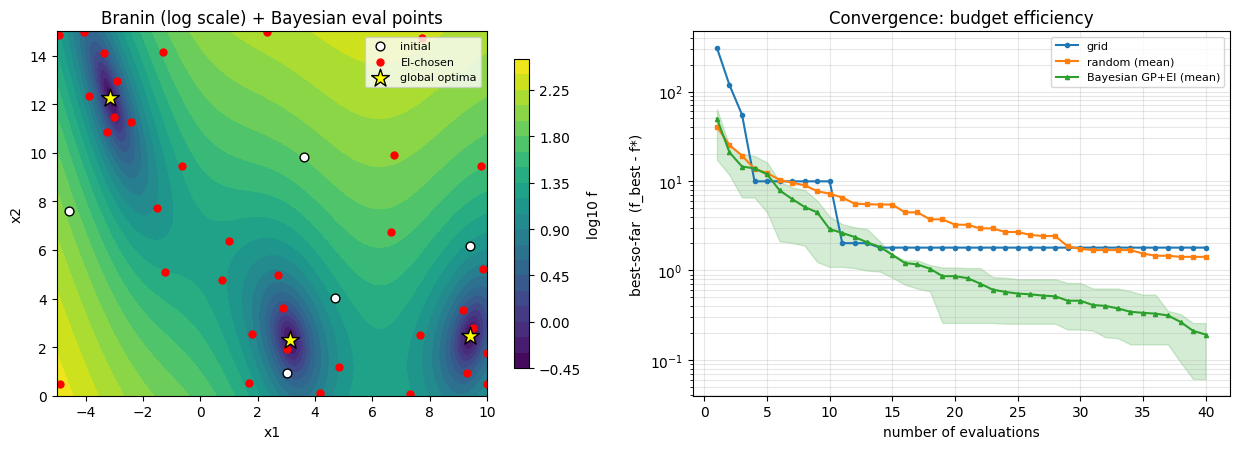

In [4]:
# --- 6) 시각화 ---
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) Branin 등고선 + BO(seed0)가 찍은 점
xa = np.linspace(bounds[0,0], bounds[0,1], 200)
ya = np.linspace(bounds[1,0], bounds[1,1], 200)
XA, YA = np.meshgrid(xa, ya)
ZA = branin(np.column_stack([XA.ravel(), YA.ravel()])).reshape(XA.shape)
cs = ax[0].contourf(XA, YA, np.log10(ZA+1e-6), levels=25, cmap='viridis')
ax[0].scatter(last_X[:n_init,0], last_X[:n_init,1], c='white', s=40, edgecolor='k', label="initial")
ax[0].scatter(last_X[n_init:,0], last_X[n_init:,1], c='red', s=25, label="EI-chosen")
opt_x = np.array([[-np.pi,12.275],[np.pi,2.275],[9.42478,2.475]])
ax[0].scatter(opt_x[:,0], opt_x[:,1], marker='*', s=180, c='yellow', edgecolor='k', label="global optima")
ax[0].set_xlabel("x1"); ax[0].set_ylabel("x2")
ax[0].set_title("Branin (log scale) + Bayesian eval points")
ax[0].legend(fontsize=8, loc='upper right')
fig.colorbar(cs, ax=ax[0], shrink=0.85, label="log10 f")

# (b) 수렴곡선
ev = np.arange(1, N+1)
ax[1].plot(ev, grid_best - f_opt, 'o-', ms=3, label="grid")
ax[1].plot(ev, rand_best - f_opt, 's-', ms=3, label="random (mean)")
ax[1].plot(ev, bo_best  - f_opt, '^-', ms=3, label="Bayesian GP+EI (mean)")
ax[1].fill_between(ev, np.percentile(bo_curves,25,0)-f_opt,
                   np.percentile(bo_curves,75,0)-f_opt, alpha=0.2, color='tab:green')
ax[1].set_yscale('log')
ax[1].set_xlabel("number of evaluations"); ax[1].set_ylabel("best-so-far  (f_best - f*)")
ax[1].set_title("Convergence: budget efficiency")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **베이지안이 예산을 가장 효율적으로 쓴다.** best-so-far 곡선에서 GP+EI는 소수의 초기점 이후
   *가파르게* 내려가 같은 평가횟수에서 grid/random보다 전역최소($\approx0.3979$)에 먼저 근접한다.
   EI가 등고선 그림의 **세 전역 골짜기** 근처로 평가를 집중시키는 것을 확인할 수 있다.
2. **랜덤 ≥ 그리드(대개).** 그리드는 축마다 해상도가 $\sqrt N$ 로 낮아지고 결정론적이라, 최소가
   격자 사이에 있으면 놓친다. 랜덤은 어느 축으로도 촘촘해질 수 있어 저차원 구조에서 평균적으로 낫다.
3. **탐험-활용의 자동 균형.** EI는 평균이 낮은 곳(활용)과 불확실성이 큰 곳(탐험)을 함께 보상한다.
   초반엔 넓게 탐험하다 점차 유망 영역으로 수렴하는 것이 EI-선택점의 분포에서 드러난다.
   단 대리모형 비용이 있으므로, 평가가 *싸면* 랜덤이 더 실용적일 수 있다(No Free Lunch).

> **결론**: 평가가 비싼 하이퍼파라미터 탐색에서 **베이지안 최적화(GP+EI)** 는 과거 평가로 대리모형을 세워 *다음에 어디를 볼지* 를 정보이론적으로 고른다 — 빠듯한 예산에서 grid·random을 앞선다.

**다음 Day로**: §14.2에서 불확실성(부트스트랩)·모델복잡도(GCV)·탐색효율(BO)을 다뤘다. 다음 절 §14.3에서는
이 도구들을 결합한 **엔드투엔드 사례연구**(데이터 → 모델선택 → 예측+불확실성 → 하이퍼파라미터 조정)로
응용 챕터를 이어간다.